Data Science

In [8]:
import pandas as pd
from matplotlib import pyplot as plt

In [9]:
file_path = "../data/eistage.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    encoding="utf-8",
    low_memory=False,
    skiprows=[0,1],
    usecols=[3,5,6],
    nrows=70,
    names=["year", "heat_days", "ice_days"],
    parse_dates=["year"]
    )

Überblick verschaffen

In [10]:
df.head()

,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46
2,1957-01-01,10,20
3,1958-01-01,9,11
4,1959-01-01,5,17


In [11]:
df.tail()

,year,heat_days,ice_days
65,2020-01-01,21,3
66,2021-01-01,24,7
67,2022-01-01,31,6
68,2023-01-01,32,2
69,2024-01-01,45,2


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   year       70 non-null     datetime64[us]
 1   heat_days  70 non-null     int64         
 2   ice_days   70 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.8 KB


In [13]:
df.describe()

,year,heat_days,ice_days
count,70,70.000000,70.000000
mean,1989-07-02 05:49:42.857142,15.371429,20.414286
min,1955-01-01 00:00:00,0.000000,2.000000
25%,1972-04-01 12:00:00,6.500000,12.250000
50%,1989-07-02 12:00:00,13.000000,19.500000
75%,2006-10-01 18:00:00,21.000000,25.000000
max,2024-01-01 00:00:00,45.000000,63.000000
std,NaN,11.007470,12.062029


## Daten manipulieren

### Projection

In [14]:
df["heat_days"].describe()

count    70.000000
mean     15.371429
std      11.007470
min       0.000000
25%       6.500000
50%      13.000000
75%      21.000000
max      45.000000
Name: heat_days, dtype: float64

In [15]:
namensliste = ["heat_days", "ice_days"]


df[namensliste]

,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


In [16]:
df[["heat_days", "ice_days"]]

,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


### Restriction

In [17]:
df_new = df.loc[(df["heat_days"] > 10)]

In [18]:
df_new.loc[df["ice_days"] < 5]

,year,heat_days,ice_days
19,1974-01-01,11,3
60,2015-01-01,42,2
64,2019-01-01,38,3
65,2020-01-01,21,3
68,2023-01-01,32,2
69,2024-01-01,45,2


In [19]:
df.loc[(df["heat_days"] > 10)].loc[df["ice_days"] < 5]

,year,heat_days,ice_days
19,1974-01-01,11,3
60,2015-01-01,42,2
64,2019-01-01,38,3
65,2020-01-01,21,3
68,2023-01-01,32,2
69,2024-01-01,45,2


In [20]:
df.iloc[4]

year         1959-01-01 00:00:00
heat_days                      5
ice_days                      17
Name: 4, dtype: object

### Mapping

In [21]:
df.head()

,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46
2,1957-01-01,10,20
3,1958-01-01,9,11
4,1959-01-01,5,17


In [22]:
df["extremwetter_tage"] = df["heat_days"] + df["ice_days"]

In [23]:
df.head()

,year,heat_days,ice_days,extremwetter_tage
0,1955-01-01,1,25,26
1,1956-01-01,3,46,49
2,1957-01-01,10,20,30
3,1958-01-01,9,11,20
4,1959-01-01,5,17,22


In [24]:
df["neue"] = list(range(70))

In [25]:
df

,year,heat_days,ice_days,extremwetter_tage,neue
0,1955-01-01,1,25,26,0
1,1956-01-01,3,46,49,1
2,1957-01-01,10,20,30,2
3,1958-01-01,9,11,20,3
4,1959-01-01,5,17,22,4
...,...,...,...,...,...
65,2020-01-01,21,3,24,65
66,2021-01-01,24,7,31,66
67,2022-01-01,31,6,37,67
68,2023-01-01,32,2,34,68


## Daten analysieren

<Axes: >

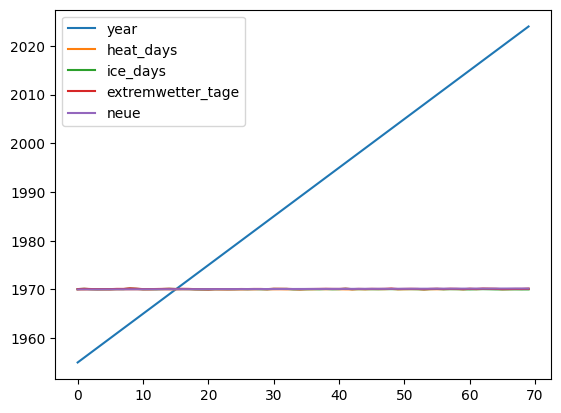

In [26]:
df.plot()

<Axes: >

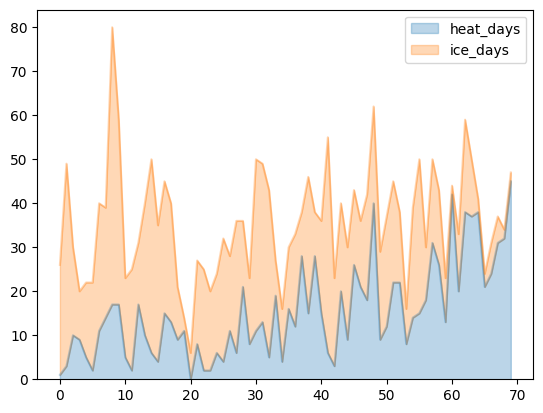

In [27]:
df[["heat_days","ice_days"]].plot(kind="area", alpha=0.3)

FileNotFoundError: [Errno 2] No such file or directory: '../img/rolling_plot.png'

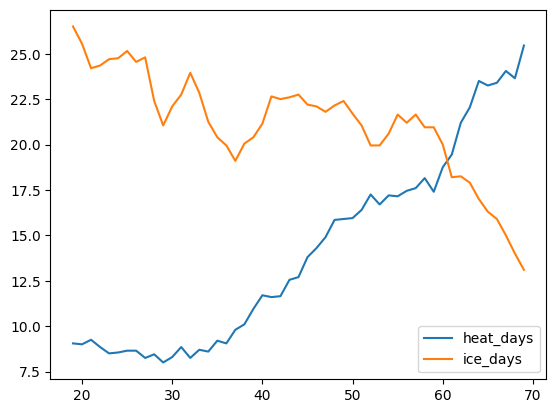

In [28]:
df[["heat_days","ice_days"]].rolling(20).mean().plot()
plt.savefig("../img/rolling_plot.png")

<Axes: >

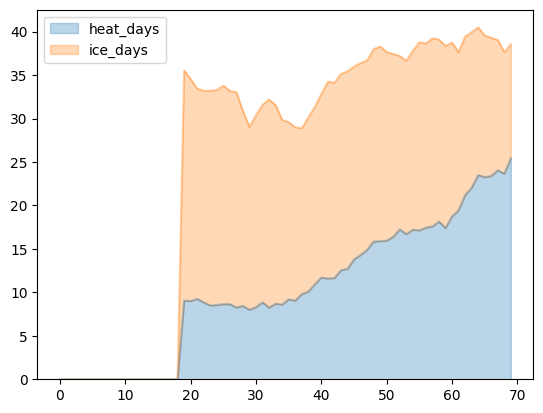

In [29]:
df[["heat_days","ice_days"]].rolling(20).mean().plot(kind="area", alpha=0.3)

<Axes: ylabel='Frequency'>

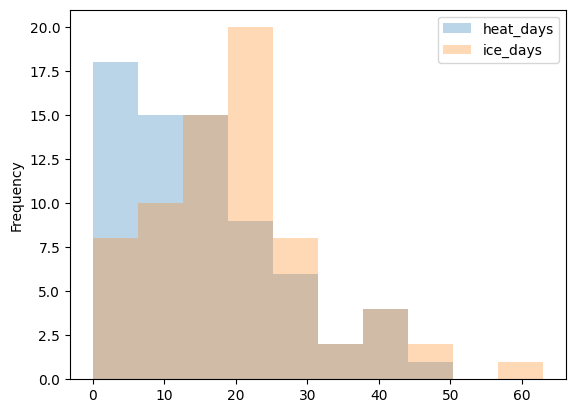

In [72]:
df[["heat_days","ice_days"]].plot(kind="hist", alpha=0.3)

<Axes: >

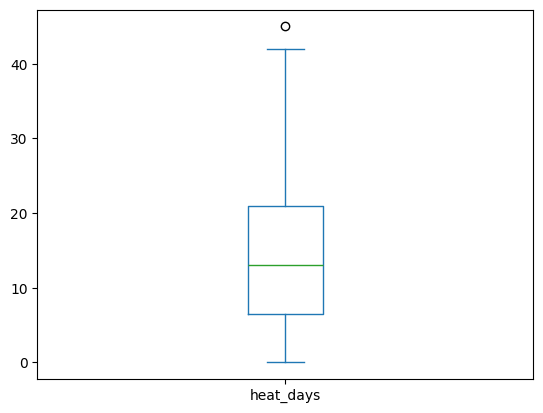

In [68]:
df["heat_days"].plot(kind="box")

<Axes: >

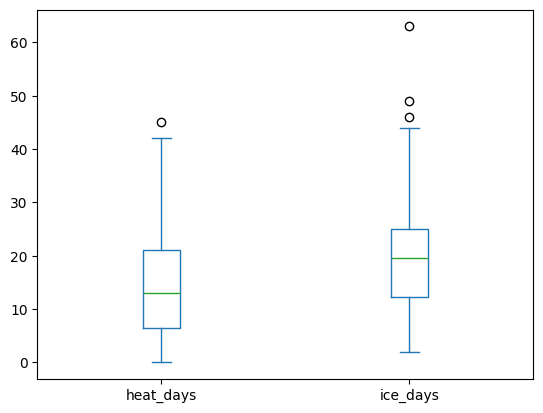

In [70]:
df[["heat_days","ice_days"]].plot(kind="box")